# Valorización de viviendas en Cercado de Lima

## Lectura de datos


In [1]:
from datetime import datetime
import pandas as pd

In [2]:
df = pd.read_excel('Predios_Cercado_de_Lima_Ene-Mar_2025_4.xlsx')

In [3]:
df.columns = ['num_registro', 'fecha_adquisicion', 'fecha_declaracion', 'num_persona','tipo_propietario', 'pct_propiedad', 'num_predio', 'cod_uso_predio','uso_predio', 'area_terreno', 'area_comun_terreno', 'area_construida','area_comun_construida', 'area_total_construida', 'pisos','anio_construccion', 'mayor_anio_construccion', 'material_predio','valor_terreno', 'valor_construccion_dep', 'valor_obras_comp','autovaluo', 'afecto_imp_predial']
df.head()

,num_registro,fecha_adquisicion,fecha_declaracion,num_persona,tipo_propietario,pct_propiedad,num_predio,cod_uso_predio,uso_predio,area_terreno,...,area_total_construida,pisos,anio_construccion,mayor_anio_construccion,material_predio,valor_terreno,valor_construccion_dep,valor_obras_comp,autovaluo,afecto_imp_predial
0,4470123114,2003-10-08,2007-04-27 08:49:00,6297598622,Propietario Único,100.00,5394658088,10101,Vivienda,40.00,...,40.00,1,2005.0,2005.0,Madera u otros,7400.00,5976.96,0.00,13376.96,N
1,3278827181,2007-02-15,2009-03-16 09:50:00,8518470230,Condómino,33.34,7776034160,10101,Vivienda,0.00,...,96.08,4,2006.0,2006.0,Concreto,8860.67,87527.55,1123.46,97511.68,S
2,9010805437,2009-04-06,2009-05-05 12:25:00,7290930932,Propietario Único,100.00,4928708754,10101,Vivienda,23.48,...,57.00,1,1965.0,1965.0,Ladrillo,6973.56,29012.37,0.00,35985.93,S
3,8960657151,1995-12-31,2012-04-09 15:15:00,8490356621,Propietario Único,100.00,6171978289,20201,Local de servicios (empresarial o profesional),0.00,...,18.00,1,1984.0,1984.0,Ladrillo,4884.75,7093.01,1686.31,13664.07,S
4,4085147639,2001-09-25,2007-03-28 08:19:00,5471080960,Propietario Único,100.00,3842922668,10101,Vivienda,0.00,...,56.53,2,1959.0,1959.0,Ladrillo,8257.92,21872.59,0.00,30130.51,S


In [4]:
df.isna().sum()

num_registro                  0
fecha_adquisicion             0
fecha_declaracion             0
num_persona                   0
tipo_propietario              0
pct_propiedad                 0
num_predio                    0
cod_uso_predio                0
uso_predio                    0
area_terreno                  0
area_comun_terreno            0
area_construida               0
area_comun_construida         0
area_total_construida         0
pisos                         0
anio_construccion          2996
mayor_anio_construccion    2996
material_predio               0
valor_terreno                 0
valor_construccion_dep        0
valor_obras_comp              0
autovaluo                     0
afecto_imp_predial            0
dtype: int64

# Limpieza de datos

In [5]:
df_new = df.drop(columns = ['num_registro','num_persona','num_predio','valor_terreno','valor_construccion_dep','valor_obras_comp'])
# 3. Convertir las columnas a formato de fecha (datetime)
# Usamos errors='coerce' por si hay algún dato mal escrito o vacío


df_new['fecha_adquisicion'] = pd.to_datetime(df_new['fecha_adquisicion'], errors='coerce')
df_new['fecha_declaracion'] = pd.to_datetime(df_new['fecha_declaracion'], errors='coerce')

# 4. Obtener la fecha de hoy
hoy = datetime.now()

# 5. Realizar las restas
# Restar dos columnas de fecha entre sí
df_new['Dias_entre_fechas'] = (df_new['fecha_adquisicion'] - df_new['fecha_declaracion']).dt.days

# Restar fecha actual vs fecha de adquisición
df_new['Antiguedad_Adquisicion_Dias'] = (hoy - df_new['fecha_adquisicion']).dt.days

# Restar fecha actual vs fecha de declaración
df_new['Antiguedad_Declaracion_Dias'] = (hoy - df_new['fecha_declaracion']).dt.days

df_new['ant_constru'] = (hoy.year - df_new['mayor_anio_construccion'])
df_new.drop(columns=['fecha_declaracion','fecha_adquisicion','anio_construccion','mayor_anio_construccion'], inplace=True)


uso_map = {
    # VIVIENDA
    'Vivienda':                          'Vivienda',
    'Deposito de vivienda':              'Vivienda',
    'Vivienda colectiva - habitaciones': 'Vivienda',
    'Aires':                             'Vivienda',
    # COMERCIAL
    'Bodega':                            'Comercial',
    'Tienda por departamentos, supermercado, hiperbodega y similares': 'Comercial',
    'Puesto (o stand) en galería comercial':  'Comercial',
    'Puesto (o stand) en mercado o campo ferial': 'Comercial',
    'Galería comercial':                 'Comercial',
    'Mercado o campo ferial':            'Comercial',
    'Centro comercial':                  'Comercial',
    'Bazar y regalos':                   'Comercial',
    'Comercial - no identificado':       'Comercial',
    'Otros usos comerciales no especificados': 'Comercial',
    # SERVICIOS
    'Oficina':                           'Servicios',
    'Local de servicios (empresarial o profesional)': 'Servicios',
    'Estacionamiento de oficinas':       'Servicios',
    'Depósito de oficina':               'Servicios',
    'Agencia de entidad financiera':     'Servicios',
    'Sede de entidad financiera':        'Servicios',
    'Agencia de seguros o afp':          'Servicios',
    'Correo o teléfono':                 'Servicios',
    'Internet':                          'Servicios',
    'Centro de estética':                'Servicios',
    'Lavanderia de carros':              'Servicios',
    'Ventas de departamentos':           'Servicios',
    # INDUSTRIAL
    'Industria manufacturera':           'Industrial',
    'Taller':                            'Industrial',
    'Almacén o depósito':                'Industrial',
    'Tendal':                            'Industrial',
    'Chatarrerías':                      'Industrial',
    'Grifo venta de combustibles para vehiculos': 'Industrial',
    'Local venta de combustibles de uso doméstico': 'Industrial',
    'Distribución o transmisión de energía eléctrica': 'Industrial',
    'Sub-estación eléctrica o telefónica': 'Industrial',
    'Centro de captación, purificación y distribución de agua': 'Industrial',
    'Laboratorio de ensayos ambientales y similares': 'Industrial',
    # EDUCACIÓN
    'Educación inicial, primaria y/o secundaria': 'Educación',
    'Educación técnica y cenecapes':     'Educación',
    'Educación superior (universitaria o instituto)': 'Educación',
    'Educación pre universitaria (academia)': 'Educación',
    'Otros usos educativos nep':         'Educación',
    'Cuna':                              'Educación',
    # SALUD
    'Hospital o clínica':                'Salud',
    'Centro de salud':                   'Salud',
    'Centro veterinario':                'Salud',
    'Hospicio, albergue, puericultorio o asilo': 'Salud',
    'Centro de rehabilitación y asistencia social (c.r.a.s.-cárceles)': 'Salud',
    'Otros usos de salud nep':           'Salud',
    'Comedor popular':                   'Salud',
    'Centro de asistencia social':       'Salud',
    # RECREACIÓN
    'Restaurantes, bares y cantinas':    'Recreación',
    'Bingo, casino de juego, pinball, tragamonedas o similar': 'Recreación',
    'Club, círculo o centro deportivo':  'Recreación',
    'Club social':                       'Recreación',
    'Gimnasio y similares':              'Recreación',
    'Cine':                              'Recreación',
    'Teatro':                            'Recreación',
    'Cafe teatro, cabaret, centro nocturno, boite': 'Recreación',
    'Peña, discoteca, salón de bailes o similares': 'Recreación',
    'Museo':                             'Recreación',
    'Centro cultural':                   'Recreación',
    'Sala de exposición, galería de arte': 'Recreación',
    'Biblioteca':                        'Recreación',
    'Estadio, hipódromo o coliseo':      'Recreación',
    'Otros usos deportivos nep':         'Recreación',
    'Otros servicios de recreación o esparcimiento nep': 'Recreación',
    'Otros usos culturales nep':         'Recreación',
    'Radio o televisión':                'Recreación',
    'Periodismo':                        'Recreación',
    # TERRENO SIN CONSTRUIR
    'Terreno sin construir':             'Sin construir',
    'Cochera':                           'Sin construir',
    'Playa o edificio de estacionamiento': 'Sin construir',
}
df_new.drop(columns=['cod_uso_predio'], inplace=True)
df_new['uso_predio'] = df_new['uso_predio'].map(uso_map).fillna('Otros')

In [6]:
df_new.to_csv('clean_data.csv', index=False)

# Modelo 1: Random Forest puro


MÉTRICAS DEL MODELO: SOLO VIVIENDAS (Test 20%)
MAE (Error Absoluto Medio)  : 7,928.27
RMSE (Raíz del Error Cuadrático): 16,556.00
R² (Coeficiente de Determinación): 0.9398

Importancia de las variables (Top 10):
                       Variable  Importancia
2         area_total_construida     0.798922
14     material_predio_Concreto     0.035679
1                  area_terreno     0.034006
7                   ant_constru     0.030239
15     material_predio_Ladrillo     0.027396
8                pct_area_comun     0.014256
4             Dias_entre_fechas     0.013197
6   Antiguedad_Declaracion_Dias     0.012483
5   Antiguedad_Adquisicion_Dias     0.011002
9    ratio_construccion_terreno     0.009536


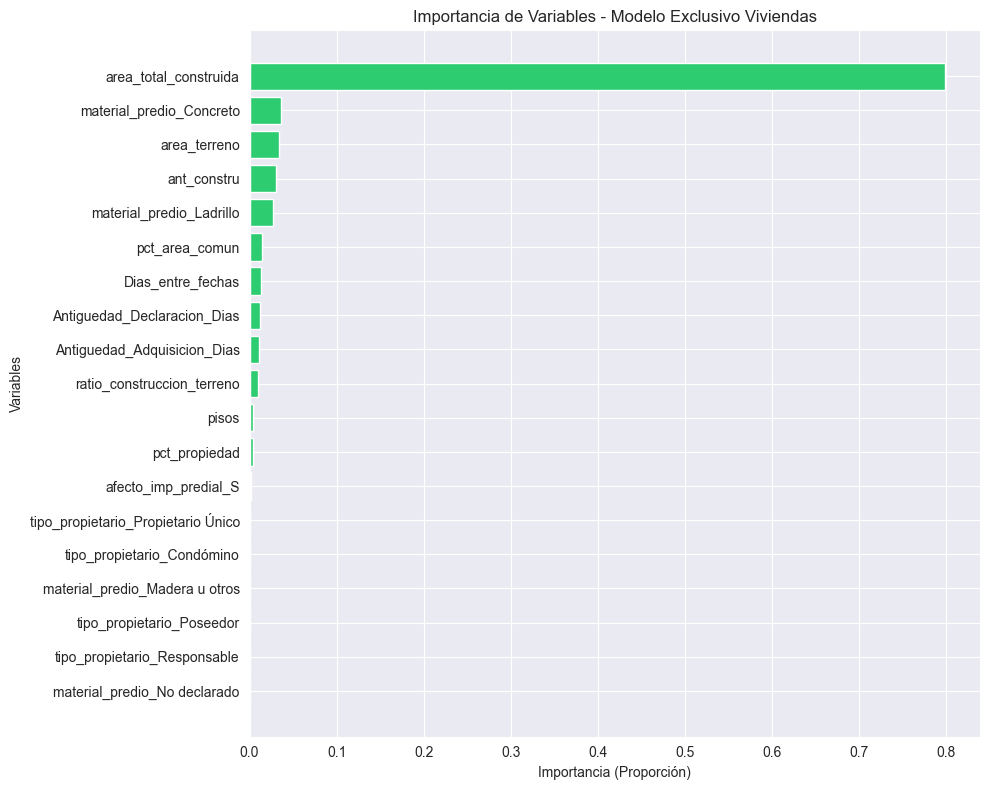

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Cargar datos
df_raw = df_new.copy()

# ==========================================
# 2. FILTRO EXCLUSIVO Y LIMPIEZA DE OUTLIERS
# ==========================================
# Nos quedamos únicamente con las viviendas
df_raw = df_raw[df_raw['uso_predio'] == 'Vivienda'].copy()

# Eliminamos la columna 'uso_predio' porque ahora tiene un solo valor y no aporta información
df_raw = df_raw.drop(columns=['uso_predio'])

# Calculamos el límite superior (Percentil 99) SOLO para las viviendas
limite_area = df['area_total_construida'].quantile(0.99)
limite_autovaluo = df_raw['autovaluo'].quantile(0.99)

# Filtramos para descartar el 1% de valores anómalos o errores de digitación
df_raw = df_raw[(df_raw['area_total_construida'] <= limite_area) & (df_raw['autovaluo'] <= limite_autovaluo)]

# 3. Imputación de nulos
df_raw['ant_constru'] = df_raw['ant_constru'].fillna(df_raw['ant_constru'].median())

# ==========================================
# 4. FEATURE ENGINEERING
# ==========================================
df_raw['pct_area_comun'] = np.where(
    df_raw['area_total_construida'] > 0,
    df_raw['area_comun_construida'] / df_raw['area_total_construida'],
    0
)

df_raw['ratio_construccion_terreno'] = np.where(
    df_raw['area_terreno'] > 0,
    df_raw['area_total_construida'] / df_raw['area_terreno'],
    0
)

# Eliminar variables redundantes para evitar multicolinealidad
columnas_a_eliminar = ['area_construida', 'area_comun_construida', 'area_comun_terreno']
df_raw = df_raw.drop(columns=columnas_a_eliminar)

# ==========================================
# 5. TRANSFORMACIÓN LOGARÍTMICA
# ==========================================
numerical_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns.tolist()
target_col = 'autovaluo'

df_log = df_raw.copy()

for col in numerical_cols:
    min_val = df_log[col].min()
    if min_val <= 0:
        df_log[col] = np.log1p(df_log[col] - min_val)
    else:
        df_log[col] = np.log1p(df_log[col])

# ==========================================
# 6. CODIFICACIÓN DE CATEGÓRICAS Y PARTICIÓN
# ==========================================
categorical_cols = df_log.select_dtypes(include=['str', 'category']).columns.tolist()

# Aplicar get_dummies
df_final = pd.get_dummies(df_log, columns=categorical_cols, drop_first=True)

# El resto del código sigue igual...
X = df_final.drop(columns=[target_col])
y = df_final[target_col]
# Partición 80% Entrenamiento / 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ==========================================
# 7. ENTRENAMIENTO DEL MODELO
# ==========================================

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ==========================================
# 8. PREDICCIÓN Y EVALUACIÓN DE MÉTRICAS
# ==========================================
y_pred_log = rf.predict(X_test)

# Revertimos el logaritmo (expm1) para evaluar el error en la escala real
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_rf = mean_absolute_error(y_test_real, y_pred_real)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_rf = r2_score(y_test, y_pred_log)

print("\n" + "="*45)
print("MÉTRICAS DEL MODELO: SOLO VIVIENDAS (Test 20%)")
print("="*45)
print(f"MAE (Error Absoluto Medio)  : {mae_rf:,.2f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse_rf:,.2f}")
print(f"R² (Coeficiente de Determinación): {r2_rf:.4f}")
print("="*45 + "\n")

# ==========================================
# 9. IMPORTANCIA DE VARIABLES
# ==========================================
feature_importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Importancia de las variables (Top 10):")
print(feature_importance_df.head(10))

# Graficar
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Variable'], feature_importance_df['Importancia'], color='#2ecc71')
plt.xlabel('Importancia (Proporción)')
plt.ylabel('Variables')
plt.title('Importancia de Variables - Modelo Exclusivo Viviendas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Modelo 2: XGBoost


MÉTRICAS DEL MODELO
MAE (Error Absoluto Medio)  : 10,933.00
RMSE (Raíz del Error Cuadrático): 19,226.44
R² (Coeficiente de Determinación): 0.9237

Importancia de las variables (Top 10):
                       Variable  Importancia
2         area_total_construida     0.798922
14     material_predio_Concreto     0.035679
1                  area_terreno     0.034006
7                   ant_constru     0.030239
15     material_predio_Ladrillo     0.027396
8                pct_area_comun     0.014256
4             Dias_entre_fechas     0.013197
6   Antiguedad_Declaracion_Dias     0.012483
5   Antiguedad_Adquisicion_Dias     0.011002
9    ratio_construccion_terreno     0.009536


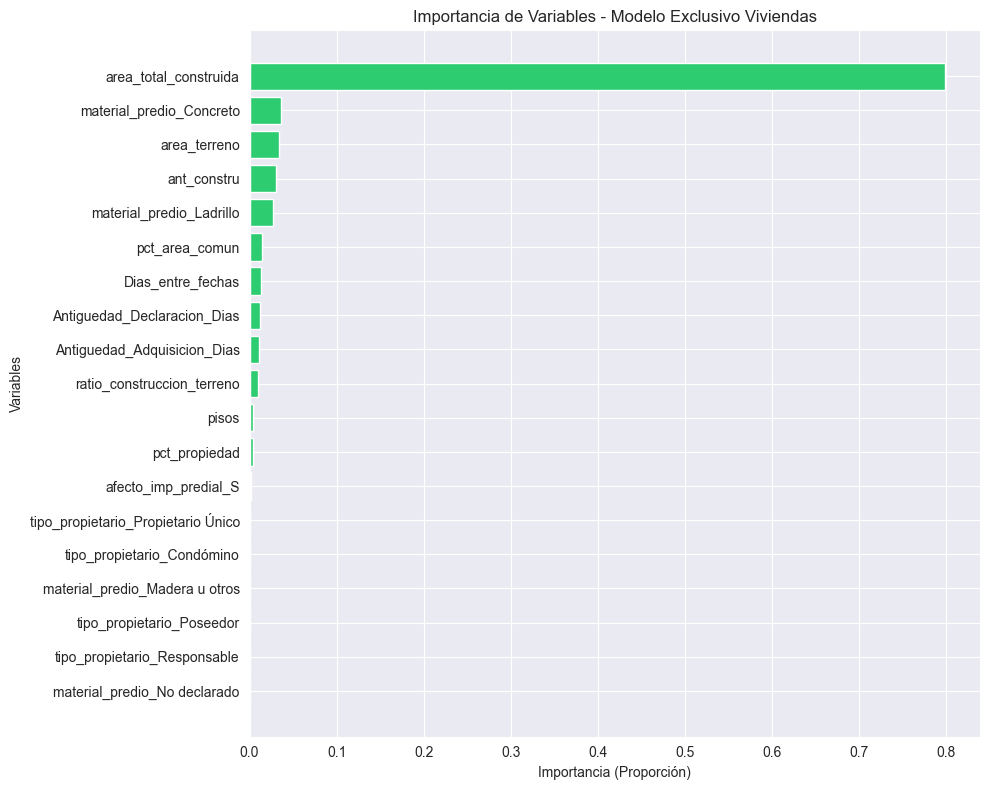

In [9]:
# ==========================================
# 7. ENTRENAMIENTO DEL MODELO
# ==========================================

import xgboost as xgb

model_xgb = xgb.XGBRegressor()
model_xgb.fit(X_train, y_train)

# ==========================================
# 8. PREDICCIÓN Y EVALUACIÓN DE MÉTRICAS
# ==========================================
y_pred_log = model_xgb.predict(X_test)

# Revertimos el logaritmo (expm1) para evaluar el error en la escala real
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_xgb = mean_absolute_error(y_test_real, y_pred_real)
rmse_xgb = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_xgb = r2_score(y_test, y_pred_log)

print("\n" + "="*45)
print("MÉTRICAS DEL MODELO")
print("="*45)
print(f"MAE (Error Absoluto Medio)  : {mae_xgb:,.2f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse_xgb:,.2f}")
print(f"R² (Coeficiente de Determinación): {r2_xgb:.4f}")
print("="*45 + "\n")

# ==========================================
# 9. IMPORTANCIA DE VARIABLES
# ==========================================
feature_importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Importancia de las variables (Top 10):")
print(feature_importance_df.head(10))

# Graficar
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Variable'], feature_importance_df['Importancia'], color='#2ecc71')
plt.xlabel('Importancia (Proporción)')
plt.ylabel('Variables')
plt.title('Importancia de Variables - Modelo Exclusivo Viviendas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
# 3. ENTRENAMIENTO DE LA RED NEURONAL (MLP)
# Arquitectura: 2 capas ocultas (64 neuronas la primera, 32 la segunda)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(64, 32),
                   activation='relu',
                   solver='adam',
                   max_iter=500,
                   early_stopping=True, # Previene sobreajuste
                   random_state=42)

print("Entrenando Red Neuronal...")
mlp.fit(X_train_scaled, y_train)

# 4. PREDICCIÓN Y MÉTRICAS
y_pred_log = mlp.predict(X_test_scaled)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_rnn = mean_absolute_error(y_test_real, y_pred_real)
rmse_rnn = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_rnn = r2_score(y_test, y_pred_log)

print("\n--- RED NEURONAL (MLPRegressor) ---")
print(f"MAE : {mae_rnn:,.2f}")
print(f"RMSE: {rmse_rnn:,.2f}")
print(f"R²  : {r2_rnn:.4f}\n")

Entrenando Red Neuronal...

--- RED NEURONAL (MLPRegressor) ---
MAE : 13,079.91
RMSE: 26,820.76
R²  : 0.8979



In [11]:
pd.DataFrame({'Random FOREST': {'r2':r2_rf, 'mae':mae_rf, 'rmse':rmse_rf},
              'XGBoost':{'r2':r2_xgb, 'mae':mae_xgb, 'rmse':rmse_xgb},
              'RNN':{'r2':r2_rnn, 'mae':mae_rnn, 'rmse':rmse_rnn},
              })

,Random FOREST,XGBoost,RNN
r2,0.939832,0.923657,0.897860
mae,7928.268660,10933.002325,13079.910068
rmse,16555.999290,19226.444639,26820.755169
